In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sentence_transformers import SentenceTransformer
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from keybert import KeyBERT

import warnings
warnings.filterwarnings('ignore')

In [10]:
df = pd.read_csv('Reviews.csv', nrows=70000).drop('Id', axis=1)
df

,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
...,...,...,...,...,...,...,...,...,...
69995,B0009YUCZA,A2A2PEE5B56MS8,Dana,0,0,5,1292803200,Great stuff!,I've been using this for years. While I have ...
69996,B0009YUCZA,ASXDTCEEWU8L4,"Beverly A. Peeples ""Gatorlaw""",0,0,5,1217894400,Wonderful Scent for a dog!,This is the best rinse for dogs that we have e...
69997,B001B185I6,A2CLYTJO7WH1KX,Mary A. Mount,7,7,5,1308009600,Wonderful dog food,Our little girl is 9 years old now. A year ago...
69998,B001B185I6,A3KO1B7QHVY0ER,Beverly Bailey,7,7,5,1262649600,Dr Harvey's Canine Health saved the life of my...,"My 5 year old Yorkshire Terrier, Molly, was di..."


In [11]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', str(text))
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    tokens = nltk.word_tokenize(text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    
    return ' '.join(tokens)


df['cleaned_text'] = df['Text'].apply(clean_text)
df = df[df['cleaned_text'].str.len() > 50]
df

,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,cleaned_text
0,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,bought several vitality canned dog food produc...
1,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled jumbo salted peanut pe...
2,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,confection around century light pillowy citrus...
3,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,looking secret ingredient robitussin believe f...
4,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,great taffy great price wide assortment yummy ...
...,...,...,...,...,...,...,...,...,...,...
69995,B0009YUCZA,A2A2PEE5B56MS8,Dana,0,0,5,1292803200,Great stuff!,I've been using this for years. While I have ...,using year tried many thing far best scent rea...
69996,B0009YUCZA,ASXDTCEEWU8L4,"Beverly A. Peeples ""Gatorlaw""",0,0,5,1217894400,Wonderful Scent for a dog!,This is the best rinse for dogs that we have e...,best rinse dog ever found use mini schnauzer s...
69997,B001B185I6,A2CLYTJO7WH1KX,Mary A. Mount,7,7,5,1308009600,Wonderful dog food,Our little girl is 9 years old now. A year ago...,little girl year old year ago ill would vomit ...
69998,B001B185I6,A3KO1B7QHVY0ER,Beverly Bailey,7,7,5,1262649600,Dr Harvey's Canine Health saved the life of my...,"My 5 year old Yorkshire Terrier, Molly, was di...",year old yorkshire terrier molly diagnosed ser...


In [12]:
tfidf = TfidfVectorizer(max_features=5000, min_df=5, max_df=0.7)
tfidf_vectors = tfidf.fit_transform(df['cleaned_text'])

In [13]:
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
sbert_vectors = sbert_model.encode(df['cleaned_text'].tolist(), show_progress_bar=True)

Batches:   0%|          | 0/2147 [00:00<?, ?it/s]

In [14]:
n_clusters = 8

kmeans_tfidf = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
tfidf_labels = kmeans_tfidf.fit_predict(tfidf_vectors)

kmeans_sbert = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
sbert_labels = kmeans_sbert.fit_predict(sbert_vectors)

In [15]:
def evaluate_clustering(vectors, labels):
    return {
        'Silhouette': silhouette_score(vectors, labels),
        'Calinski-Harabasz': calinski_harabasz_score(vectors, labels),
        'Davies-Bouldin': davies_bouldin_score(vectors, labels)
    }

tfidf_metrics = evaluate_clustering(tfidf_vectors.toarray(), tfidf_labels)
sbert_metrics = evaluate_clustering(sbert_vectors, sbert_labels)

cluster_metrics = pd.DataFrame([tfidf_metrics, sbert_metrics], index=['TF-IDF', 'SBERT'])
cluster_metrics

,Silhouette,Calinski-Harabasz,Davies-Bouldin
TF-IDF,0.013457,367.151082,8.440236
SBERT,0.042710,1749.146851,3.959131


In [16]:
def get_tfidf_cluster_top_words(cluster_num, top_n=15):
    cluster_mask = tfidf_labels == cluster_num
    cluster_tfidf = tfidf_vectors[cluster_mask]
    avg_tfidf = np.asarray(cluster_tfidf.mean(axis=0)).flatten()
    top_indices = avg_tfidf.argsort()[-top_n:][::-1]
    
    return [tfidf.get_feature_names_out()[i] for i in top_indices]

tfidf_cluster_words = {}
for i in range(n_clusters):
    tfidf_cluster_words[i] = get_tfidf_cluster_top_words(i)

In [17]:
kw_model = KeyBERT()
sbert_cluster_words = {}

for i in range(n_clusters):
    cluster_texts = df[tfidf_labels == i]['cleaned_text'].tolist()
    sample_text = ' '.join(cluster_texts[:10])
    keywords = kw_model.extract_keywords(sample_text, keyphrase_ngram_range=(1, 2), stop_words='english', top_n=15)
    sbert_cluster_words[i] = [kw[0] for kw in keywords]

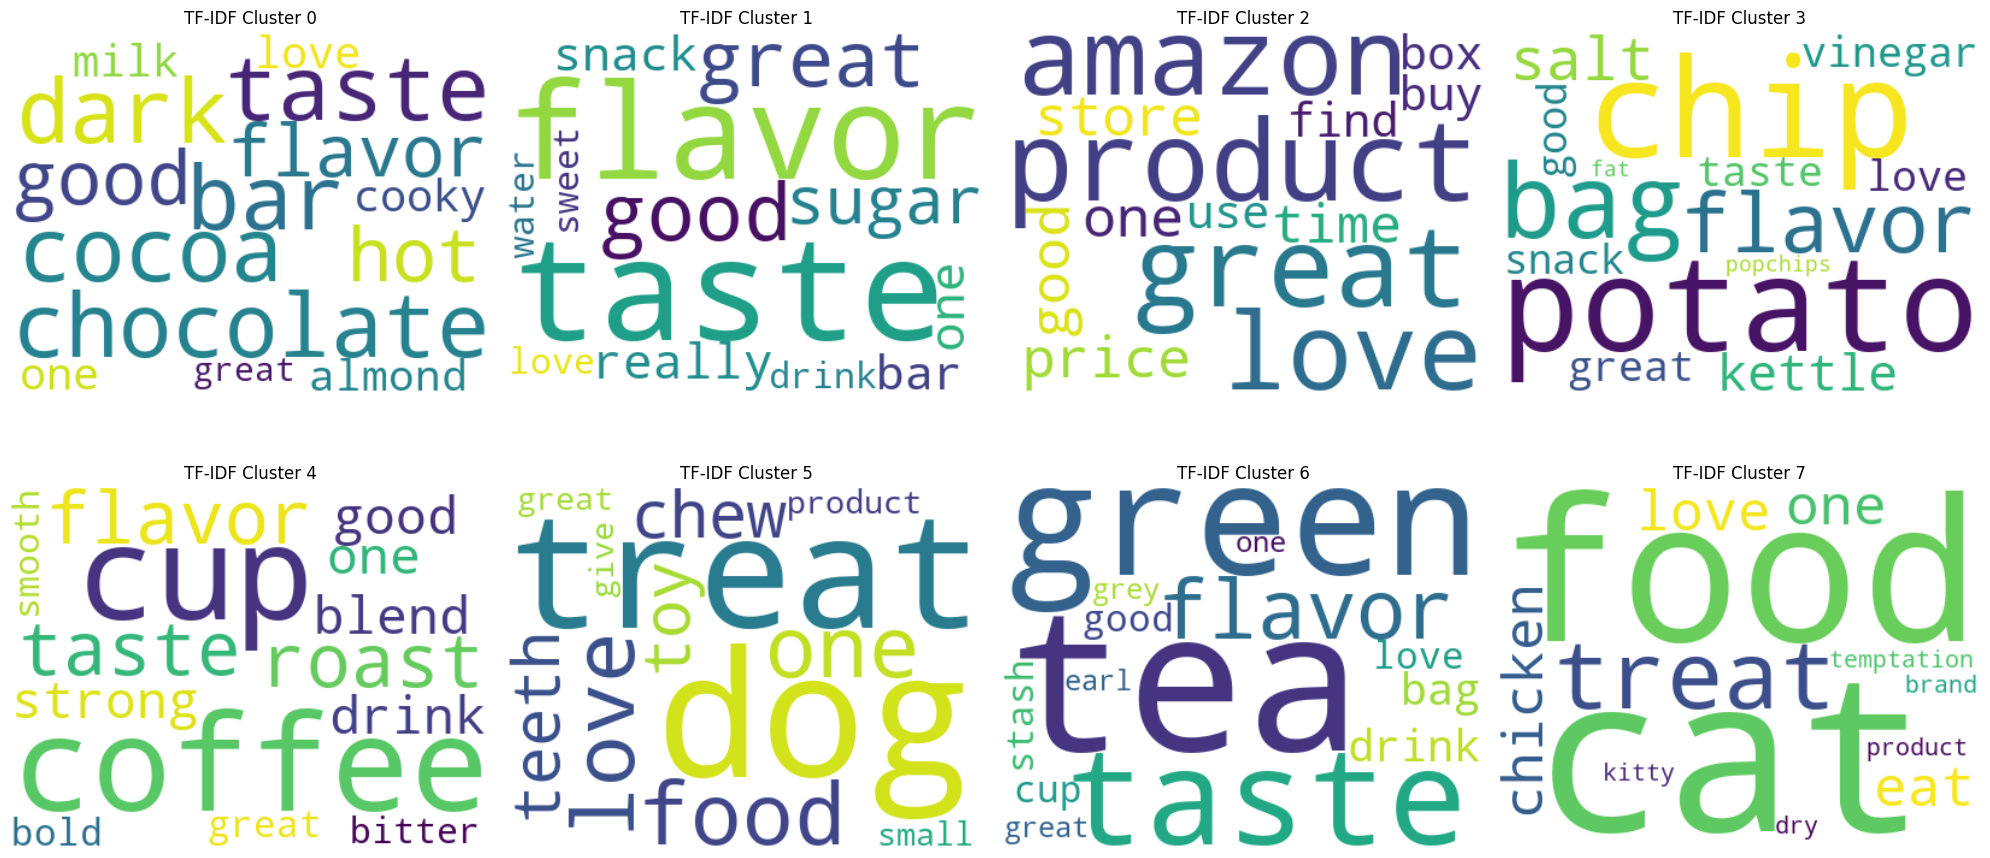

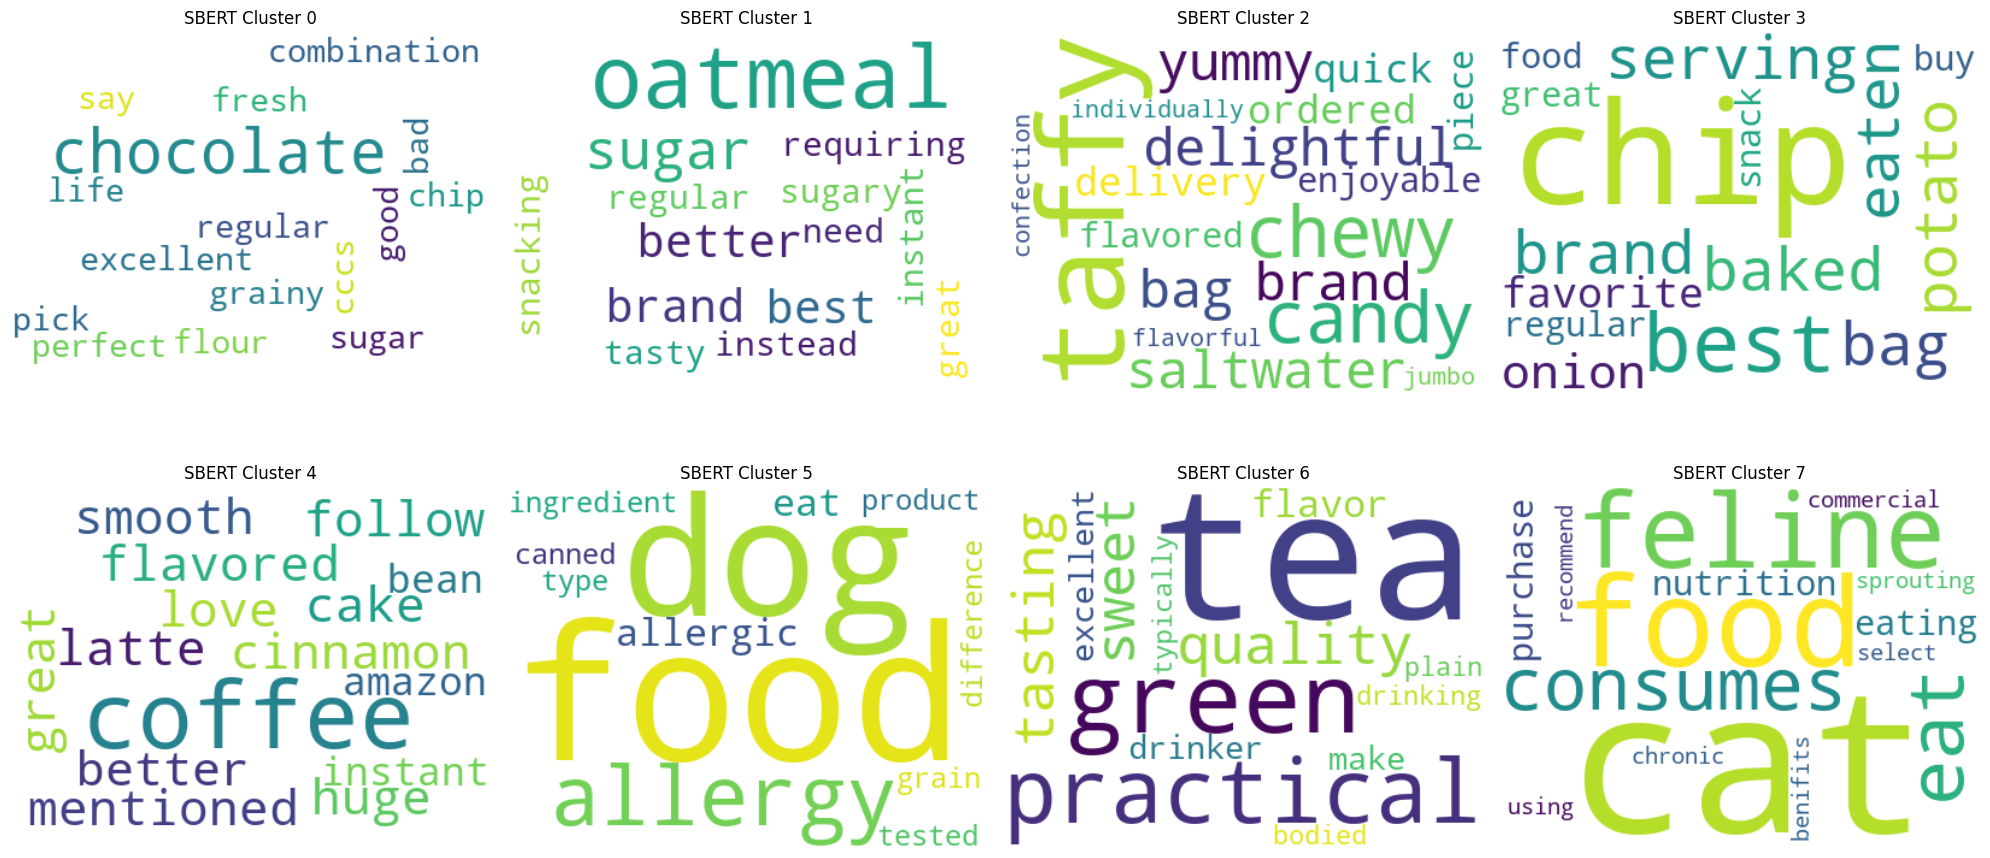

In [18]:
def plot_wordclouds(cluster_words_dict, title_prefix):
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()
    
    for i in range(n_clusters):
        if i < len(axes):
            text = ' '.join(cluster_words_dict[i])
            if text.strip():
                wc = WordCloud(width=400, height=300, background_color='white').generate(text)
                axes[i].imshow(wc, interpolation='bilinear')
                axes[i].set_title(f'{title_prefix} Cluster {i}')
                axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

plot_wordclouds(tfidf_cluster_words, 'TF-IDF')
plot_wordclouds(sbert_cluster_words, 'SBERT')

In [19]:
for i in range(min(4, n_clusters)):
    print(f"\nКластер {i}:")
    print(f"TF-IDF топ слова: {', '.join(tfidf_cluster_words[i][:10])}")
    print(f"SBERT ключевые слова: {', '.join(sbert_cluster_words[i][:10])}")
    print(f"Пример текста: {df[tfidf_labels == i]['cleaned_text'].iloc[0][:200]}...")


Кластер 0:
TF-IDF топ слова: chocolate, bar, dark, taste, like, cocoa, good, hot, flavor, cooky
SBERT ключевые слова: regular chocolate, sugar chocolate, combination chocolate, chocolate grainy, chocolate excellent, chocolate say, chocolate fresh, chocolate, chocolate perfect, chocolate chip
Пример текста: chocolate say great variety everything family love family six go fast perfect variety kit kat reeses take five...

Кластер 1:
TF-IDF топ слова: taste, like, flavor, good, great, sugar, really, one, snack, bar
SBERT ключевые слова: oatmeal best, brand oatmeal, oatmeal better, oatmeal brand, best oatmeal, oatmeal need, sugar instead, tasty oatmeal, sugar better, oatmeal great
Пример текста: looking secret ingredient robitussin believe found got addition root beer extract ordered good made cherry soda flavor medicinal...

Кластер 2:
TF-IDF топ слова: product, great, love, amazon, price, good, one, store, time, get
SBERT ключевые слова: yummy taffy, taffy delightful, brand taffy, saltwa